In [3]:
import sqlite3
import pandas as pd
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go

db_path = Path.cwd().parent / "tempo_dev.db"
conn = sqlite3.connect(db_path)

samples = pd.read_sql("SELECT * FROM health_samples ORDER BY start_date DESC LIMIT 5", conn)
samples

,uuid,type,quantity,start_date,end_date,inserted_at,updated_at
0,28142287-69EB-4829-8BD7-76F786399FC5,HKQuantityTypeIdentifierHeartRate,61.000000,2026-01-19T13:15:28Z,2026-01-19T13:15:28Z,2026-01-19T13:17:45,2026-01-19T13:17:45
1,1DD1F457-04B8-475A-9D5C-0205D0998ECC,HKQuantityTypeIdentifierHeartRate,56.000000,2026-01-19T13:10:22Z,2026-01-19T13:10:22Z,2026-01-19T13:17:45,2026-01-19T13:17:45
2,A41CBCFD-5D9C-4CD7-86C2-59ED1AA03785,HKQuantityTypeIdentifierHeartRate,66.000000,2026-01-19T13:08:33Z,2026-01-19T13:08:33Z,2026-01-19T13:17:45,2026-01-19T13:17:45
3,D67EE2C7-BBC0-4426-AAE3-52C17D0702C2,HKQuantityTypeIdentifierStepCount,142.000000,2026-01-19T13:00:30Z,2026-01-19T13:09:25Z,2026-01-19T13:18:01,2026-01-19T13:18:01
4,E4A1C857-39CA-456B-8653-991BB729AB65,HKQuantityTypeIdentifierDistanceWalkingRunning,0.067023,2026-01-19T13:00:30Z,2026-01-19T13:09:25Z,2026-01-19T13:17:45,2026-01-19T13:17:45


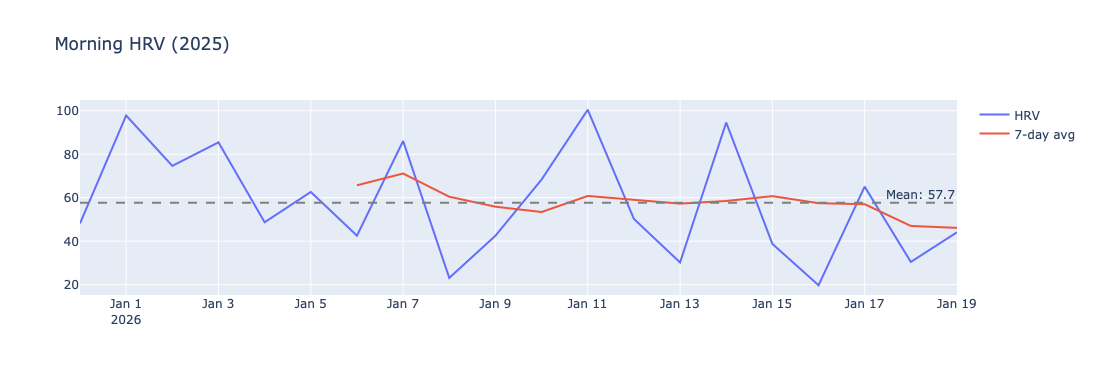

--- Aggregates
Min: 19.7
Max: 100.5
Mean: 57.7
30-day std dev: 25.4
Full year std dev: 25.4
--- Today: 44.1
7-day avg: 46.1
30-day std dev: 25.4
Difference: -2.0
Status: Normal


In [10]:
hrv = pd.read_sql("""
  SELECT date(start_date, '-5 hours') as day, quantity as value
  FROM health_samples 
  WHERE type = 'HKQuantityTypeIdentifierHeartRateVariabilitySDNN'
    AND time(start_date) BETWEEN '04:00' AND '14:00'
    AND start_date >= '2026-01-01'
  ORDER BY start_date
""", conn)

daily = hrv.groupby('day')['value'].first().reset_index()
daily['rolling_7'] = daily['value'].rolling(7).mean()
baseline = daily['value'].mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily['day'], y=daily['value'], mode='lines', name='HRV'))
fig.add_trace(go.Scatter(x=daily['day'], y=daily['rolling_7'], mode='lines', name='7-day avg'))
fig.add_hline(y=baseline, line_dash="dash", line_color="gray", annotation_text=f"Mean: {baseline:.1f}")
fig.update_layout(title='Morning HRV (2025)')
fig.show()

# Aggregates for date range
print(f"--- Aggregates")
print(f"Min: {daily['value'].min():.1f}")
print(f"Max: {daily['value'].max():.1f}")
print(f"Mean: {daily['value'].mean():.1f}")

print(f"30-day std dev: {daily['value'].tail(30).std():.1f}")
print(f"Full year std dev: {daily['value'].std():.1f}")

# Calculate for today
window = 30
recent = daily['value'].tail(window)

rolling_7 = daily['value'].tail(7).mean()
std_dev = recent.std()
today = daily['value'].iloc[-1]

diff = today - rolling_7

if diff > std_dev:
    status = "Go hard"
elif diff < -std_dev:
    status = "Recovery"
else:
    status = "Normal"

print(f"--- Today: {today:.1f}")
print(f"7-day avg: {rolling_7:.1f}")
print(f"30-day std dev: {std_dev:.1f}")
print(f"Difference: {diff:+.1f}")
print(f"Status: {status}")